In [257]:
import numpy as np
import room_acoustics_utils as utils
import pyroomacoustics as pra
import random
import matplotlib.pyplot as plt

In [258]:
room_dim = np.array([0.5, 0.5, 0.5])
head_pos = 0.5*room_dim

In [259]:
head_yaw = 0.25*np.pi
# head_yaw = 0

In [260]:
# def random_mouth_position(head_pos, head_yaw):
#     hpx, hpy, hpz = head_pos
#     rdx = random.uniform(-0.01, 0.01)
#     rdy = random.uniform(0.11, 0.15)
#     rdz = random.uniform(-0.04, -0.02)
#     x = hpx + rdx*np.cos(head_yaw) - rdy*np.sin(head_yaw)
#     y = hpy + rdx*np.sin(head_yaw) + rdy*np.cos(head_yaw)
#     z = hpz + rdz
#     return np.array([x, y, z])

def random_mouth_position(head_pos, head_yaw=0, head_pitch=0, head_roll=0):
    # Define initial mouth position relative to head center.
    rdx = random.uniform(0.11, 0.15)
    rdy = random.uniform(-0.01, 0.01)
    rdz = random.uniform(-0.04, -0.02)
    mouth_pos = np.array([rdx, rdy, rdz])
    # Define rotation matrix around vertical axis (yaw).
    rot_yaw = np.array([[np.cos(head_yaw), -np.sin(head_yaw), 0.0], [np.sin(head_yaw), np.cos(head_yaw), 0.0], [0.0, 0.0, 1.0]])
    # Define rotation matrix around lateral axis (pitch).
    rot_pitch = np.array([[np.cos(head_pitch), 0.0, np.sin(head_pitch)], [0.0, 1.0, 0.0], [-np.sin(head_pitch), 0.0, np.cos(head_pitch)]])
    # Define rotation matrix around horizontal axis (roll).
    rot_roll = np.array([[1.0, 0.0, 0.0], [0.0, np.cos(head_roll), -np.sin(head_roll)], [0.0, np.sin(head_roll), np.cos(head_roll)]])
    # Rotate mouth position.
    mouth_pos = rot_roll @ rot_pitch @ rot_yaw @ mouth_pos.T
    # Translate to head position.
    mouth_pos = mouth_pos + head_pos
    return mouth_pos


In [269]:
mouth_pos = random_mouth_position(head_pos, head_yaw=0, head_pitch=0, head_roll=0) #0.5*np.pi)

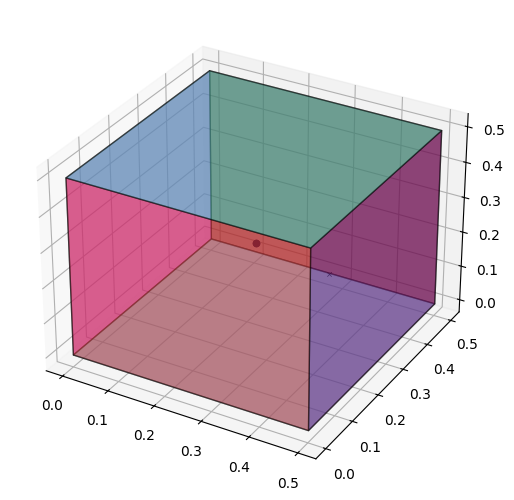

In [270]:
# VIEW FROM BEHIND
room = pra.ShoeBox(room_dim)
room.add_source(head_pos)
room.add_microphone(mouth_pos)
room.plot();

In [271]:
# # VIEW FROM ABOVE
# room = pra.ShoeBox(room_dim[:2])
# room.add_source(head_pos[:2])
# room.add_microphone(mouth_pos[:2])
# room.plot();

In [272]:
# # VIEW FROM THE RIGHT SIDE
# room = pra.ShoeBox(room_dim[1:])
# room.add_source(head_pos[1:])
# room.add_microphone(mouth_pos[1:])
# room.plot();

In [273]:
# # VIEW FROM BEHIND
# room = pra.ShoeBox(room_dim[0::2])
# room.add_source(head_pos[0::2])
# room.add_microphone(mouth_pos[0::2])
# room.plot();

In [274]:
def random_ears_position(head_pos):
    rdx = random.uniform(0.08, 0.09)
    # Define position of ears relative to head center.
    ear_center_l = np.array([- rdx, 0.0, 0.0])
    ear_center_r = np.array([+ rdx, 0.0, 0.0])
    ears_pos = np.array([ear_center_l, ear_center_r])
    # Translate position of ears.
    ears_pos = ears_pos + np.repeat(head_pos[None, ...], repeats=2, axis=0)
    return ears_pos

def define_mics_position(head_pos, head_yaw=0, head_pitch=0, head_roll=0):
    rdy = random.uniform(0.08, 0.09)
    # Define initial position of mics relative to head center.
    mic_l_dn = np.array([0.0, + rdy, - 0.01])
    mic_l_up = np.array([0.0, + rdy, + 0.01])    
    mic_r_dn = np.array([0.0, - rdy, - 0.01])
    mic_r_up = np.array([0.0, - rdy, + 0.01])
    mics_pos = np.array([mic_l_dn, mic_l_up, mic_r_dn, mic_r_up])
    # Define rotation matrix around vertical axis (yaw).
    rot_yaw = np.array([[np.cos(head_yaw), -np.sin(head_yaw), 0.0], [np.sin(head_yaw), np.cos(head_yaw), 0.0], [0.0, 0.0, 1.0]])
    # Define rotation matrix around lateral axis (pitch).
    rot_pitch = np.array([[np.cos(head_pitch), 0.0, np.sin(head_pitch)], [0.0, 1.0, 0.0], [-np.sin(head_pitch), 0.0, np.cos(head_pitch)]])
    # Define rotation matrix around horizontal axis (roll).
    rot_roll = np.array([[1.0, 0.0, 0.0], [0.0, np.cos(head_roll), -np.sin(head_roll)], [0.0, np.sin(head_roll), np.cos(head_roll)]])
    # Define full rotation matrix.
    rot_full = rot_roll @ rot_pitch @ rot_yaw
    # rot_full = rot_yaw @ rot_pitch @ rot_roll
    # Rotate position of mics.
    mics_pos = rot_full @ mics_pos.T
    # Translate position of mics.
    mics_pos = mics_pos.T + np.repeat(head_pos[None, ...], repeats=4, axis=0)
    return mics_pos


In [285]:
mics_pos = define_mics_position(head_pos, head_yaw=1.6, head_pitch=1.6, head_roll=0.8)


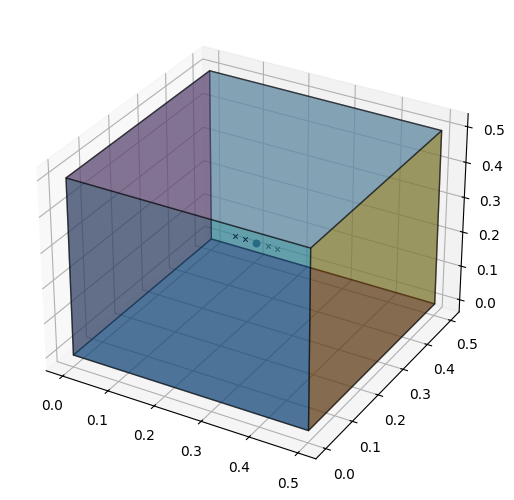

In [286]:
# Create room and add necessary sources.
room = pra.ShoeBox(room_dim)
room.add_source(head_pos)
room.add_microphone(mics_pos.T)
room.add_microphone(mics_pos.T)
room.plot();

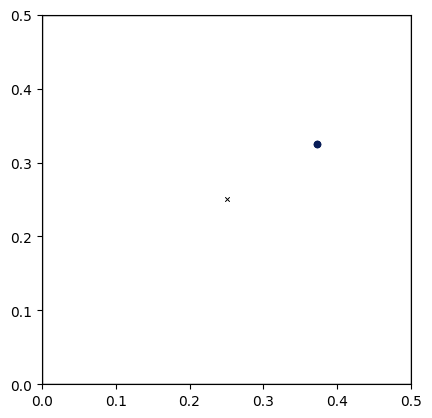

In [196]:
# SIDE VIEW
room = pra.ShoeBox(room_dim[1:])
room.add_source(mouth_pos[1:])
room.add_microphone(ears_pos[0][1:])
room.add_microphone(ears_pos[1][1:])
room.plot();